In [ ]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


SHEET_ID = "1G-pp7P9sBWLy0_ohm6vxghQdVAp0u_GDjmKuECM00lc"
GID = "465442527"
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['cidade', 'habitantes', 'industrias', 'temperatura_media', 'consumo_energia']


,cidade,habitantes,industrias,temperatura_media,consumo_energia
0,São Paulo,11450000,8500,23.5,alto
1,Rio de Janeiro,6200000,4200,26.8,alto
2,Belo Horizonte,2300000,2100,22.1,alto
3,Curitiba,1770000,1800,18.5,alto
4,Maringá,436000,850,24.2,medio


In [ ]:
# Suas novas variáveis independentes
FEATURES = ["habitantes", "industrias", "temperatura_media"]

# O que você quer prever
TARGET = "consumo_energia"

for col in FEATURES :
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())


Distribuição do target:
consumo_energia
baixo    19
medio    18
alto     15
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['alto', 'baixo', 'medio']
Total linhas válidas: 52


In [ ]:
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))


Treino: 42 | Teste: 10


In [ ]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=52) ===


,qtd,%
consumo_energia,,
baixo,19,36.5
medio,18,34.6
alto,15,28.8



=== Treino (n=42) ===


,qtd,%
consumo_energia,,
baixo,16,38.1
medio,14,33.3
alto,12,28.6



=== Teste (n=10) ===


,qtd,%
consumo_energia,,
medio,4,40.0
alto,3,30.0
baixo,3,30.0


In [ ]:
# Modelo KNN
K = 5
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [ ]:
# Avaliação
y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")

# LINHA CORRIGIDA AQUI: Adicionamos labels e zero_division
print(classification_report(
    y_test,
    y_pred,
    labels=range(len(le.classes_)), # Força a mostrar todas as classes
    target_names=le.classes_,
    zero_division=0                 # Evita avisos de divisão por zero se uma classe não aparecer
))

print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))


Features usadas: ['habitantes', 'industrias', 'temperatura_media']
Acurácia: 0.8

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       0.67      0.67      0.67         3
       medio       0.75      0.75      0.75         4

    accuracy                           0.80        10
   macro avg       0.81      0.81      0.81        10
weighted avg       0.80      0.80      0.80        10

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 2 1]
 [0 1 3]]


In [ ]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
# Exibe a cidade, as features usadas, o consumo real e o previsto
display(test_df[["cidade"] + FEATURES + [TARGET, "classe_prevista"]])

,cidade,habitantes,industrias,temperatura_media,consumo_energia,classe_prevista
0,Franca,350000,750,22.0,medio,medio
1,Anápolis,390000,800,24.1,medio,medio
2,Manaus,2060000,1800,27.8,alto,alto
3,Umuarama,112000,210,25.8,baixo,baixo
4,Cuiabá,610000,900,27.5,medio,baixo
5,Apucarana,136000,320,21.8,baixo,medio
6,Piracicaba,400000,950,22.8,medio,medio
7,Fortaleza,2420000,2200,27.1,alto,alto
8,Curitiba,1770000,1800,18.5,alto,alto
9,Santa Maria,280000,380,19.1,baixo,baixo



=== Árvore de decisão ===
Features usadas: ['habitantes', 'industrias', 'temperatura_media']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       1.00      1.00      1.00         3
       medio       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 3 0]
 [0 0 4]]


,cidade,habitantes,industrias,temperatura_media,consumo_energia,classe_prevista_arvore
0,Franca,350000,750,22.0,medio,medio
1,Anápolis,390000,800,24.1,medio,medio
2,Manaus,2060000,1800,27.8,alto,alto
3,Umuarama,112000,210,25.8,baixo,baixo
4,Cuiabá,610000,900,27.5,medio,medio
5,Apucarana,136000,320,21.8,baixo,baixo
6,Piracicaba,400000,950,22.8,medio,medio
7,Fortaleza,2420000,2200,27.1,alto,alto
8,Curitiba,1770000,1800,18.5,alto,alto
9,Santa Maria,280000,380,19.1,baixo,baixo


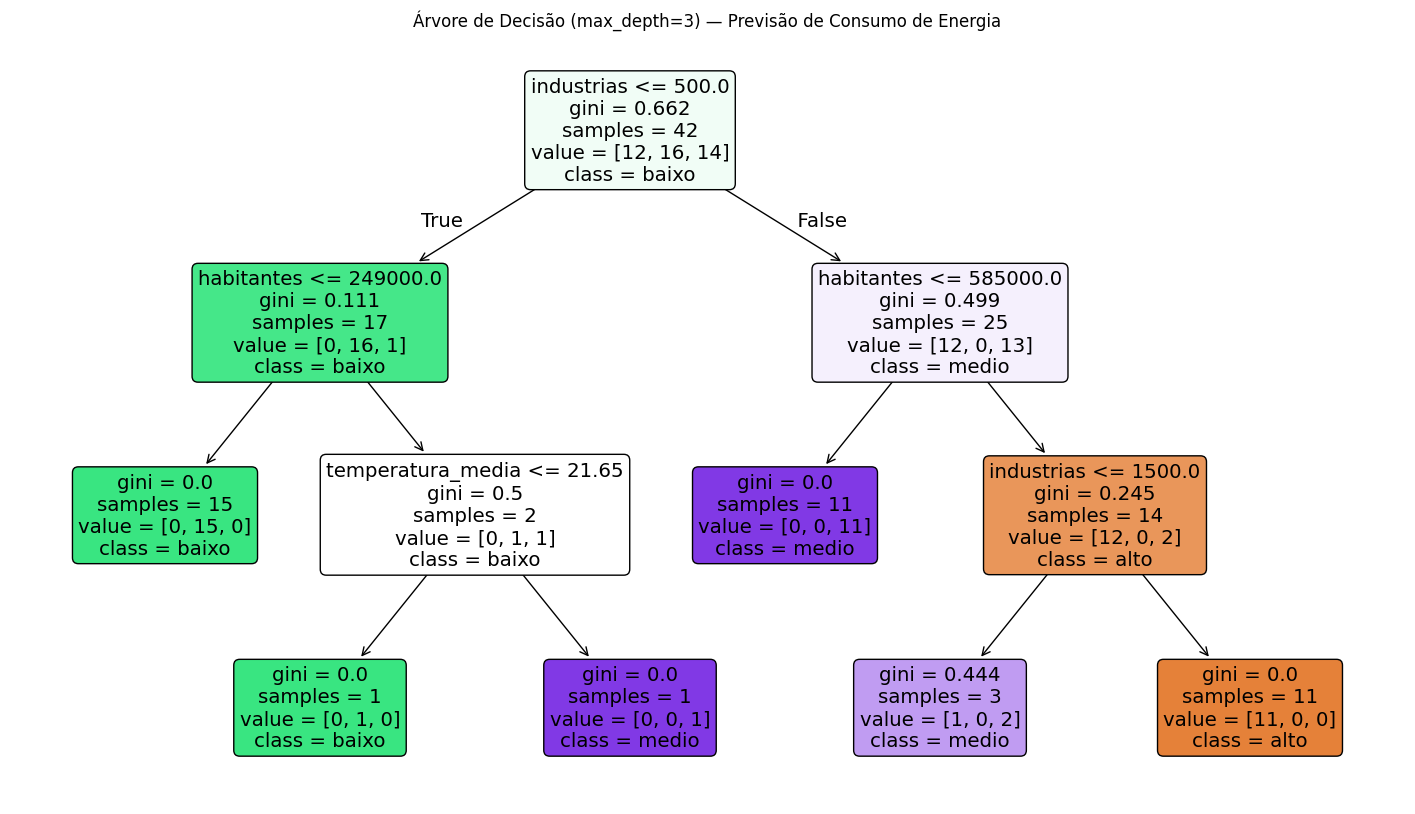

In [ ]:
# ========= Árvore de decisão =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")

# CORREÇÃO APLICADA AQUI: Adicionado labels e zero_division
print(classification_report(
    y_test,
    y_pred_tree,
    labels=range(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))

print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[["cidade"] + FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — Previsão de Consumo de Energia")
plt.show()